# 🤖 The Transformer Architecture: A Complete Visual Tutorial

**"Attention Is All You Need"** — Vaswani et al., 2017

---

This notebook covers:
- ✅ Why transformers replaced RNNs/LSTMs
- ✅ Positional Encoding (in plain English)
- ✅ Self-Attention & how Q, K, V matrices work
- ✅ Multi-Head Attention with visualizations
- ✅ Encoder & Decoder architecture
- ✅ Complete TensorFlow/Keras implementation from scratch
- ✅ Connect to Claude, GPT, HuggingFace, and Ollama
- ✅ Audio explanations via text-to-speech


In [1]:
# Install required packages (run once)
import subprocess, sys

packages = [
    'tensorflow', 'numpy', 'matplotlib', 'seaborn',
    'gtts', 'IPython', 'anthropic', 'openai',
    'requests', 'ipywidgets'
]

for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
        print(f'✓ {pkg}')
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'✓ {pkg} installed')

print('\n✅ All packages ready!')

/Users/snerur/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✓ tensorflow
✓ numpy
✓ matplotlib
✓ seaborn
✓ gtts
✓ IPython
✓ anthropic
✓ openai
✓ requests
✓ ipywidgets

✅ All packages ready!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras

# Display
from IPython.display import display, Audio, HTML, Image

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('✅ All imports successful!')
print(f'   TensorFlow version:  {tf.__version__}')
print(f'   NumPy version:       {np.__version__}')
print(f'   Keras version:       {keras.__version__}')

✅ All imports successful!
   TensorFlow version:  2.20.0
   NumPy version:       1.26.4
   Keras version:       3.13.2


---
## Chapter 1: Why Transformers? The Motivation

### The Problem with RNNs and LSTMs

Before transformers, sequence tasks (translation, summarization, Q&A) used **Recurrent Neural Networks (RNNs)** and **Long Short-Term Memory (LSTMs)**. They had three fundamental problems:

| Problem | Description |
|---------|-------------|
| **Sequential processing** | Words processed one-by-one — can't parallelize on GPUs |
| **Vanishing gradients** | Early words are "forgotten" in long sentences |
| **Fixed-size bottleneck** | The entire meaning of a long sentence compressed into one vector |

### The Transformer Solution

The transformer introduced **self-attention**: every word can directly "attend" to every other word simultaneously.

```
RNN:  Word1 → Word2 → Word3 → ... → WordN  (sequential, slow)

Transformer:
         Word1 ←→ Word2
           ↕         ↕
         Word3 ←→ Word4   (all pairs, in parallel!)
```

**Key insight**: In "The animal didn't cross the street because **it** was too tired" — what does "it" refer to? The transformer can learn this by attending to "animal" directly, no matter how far apart they are.

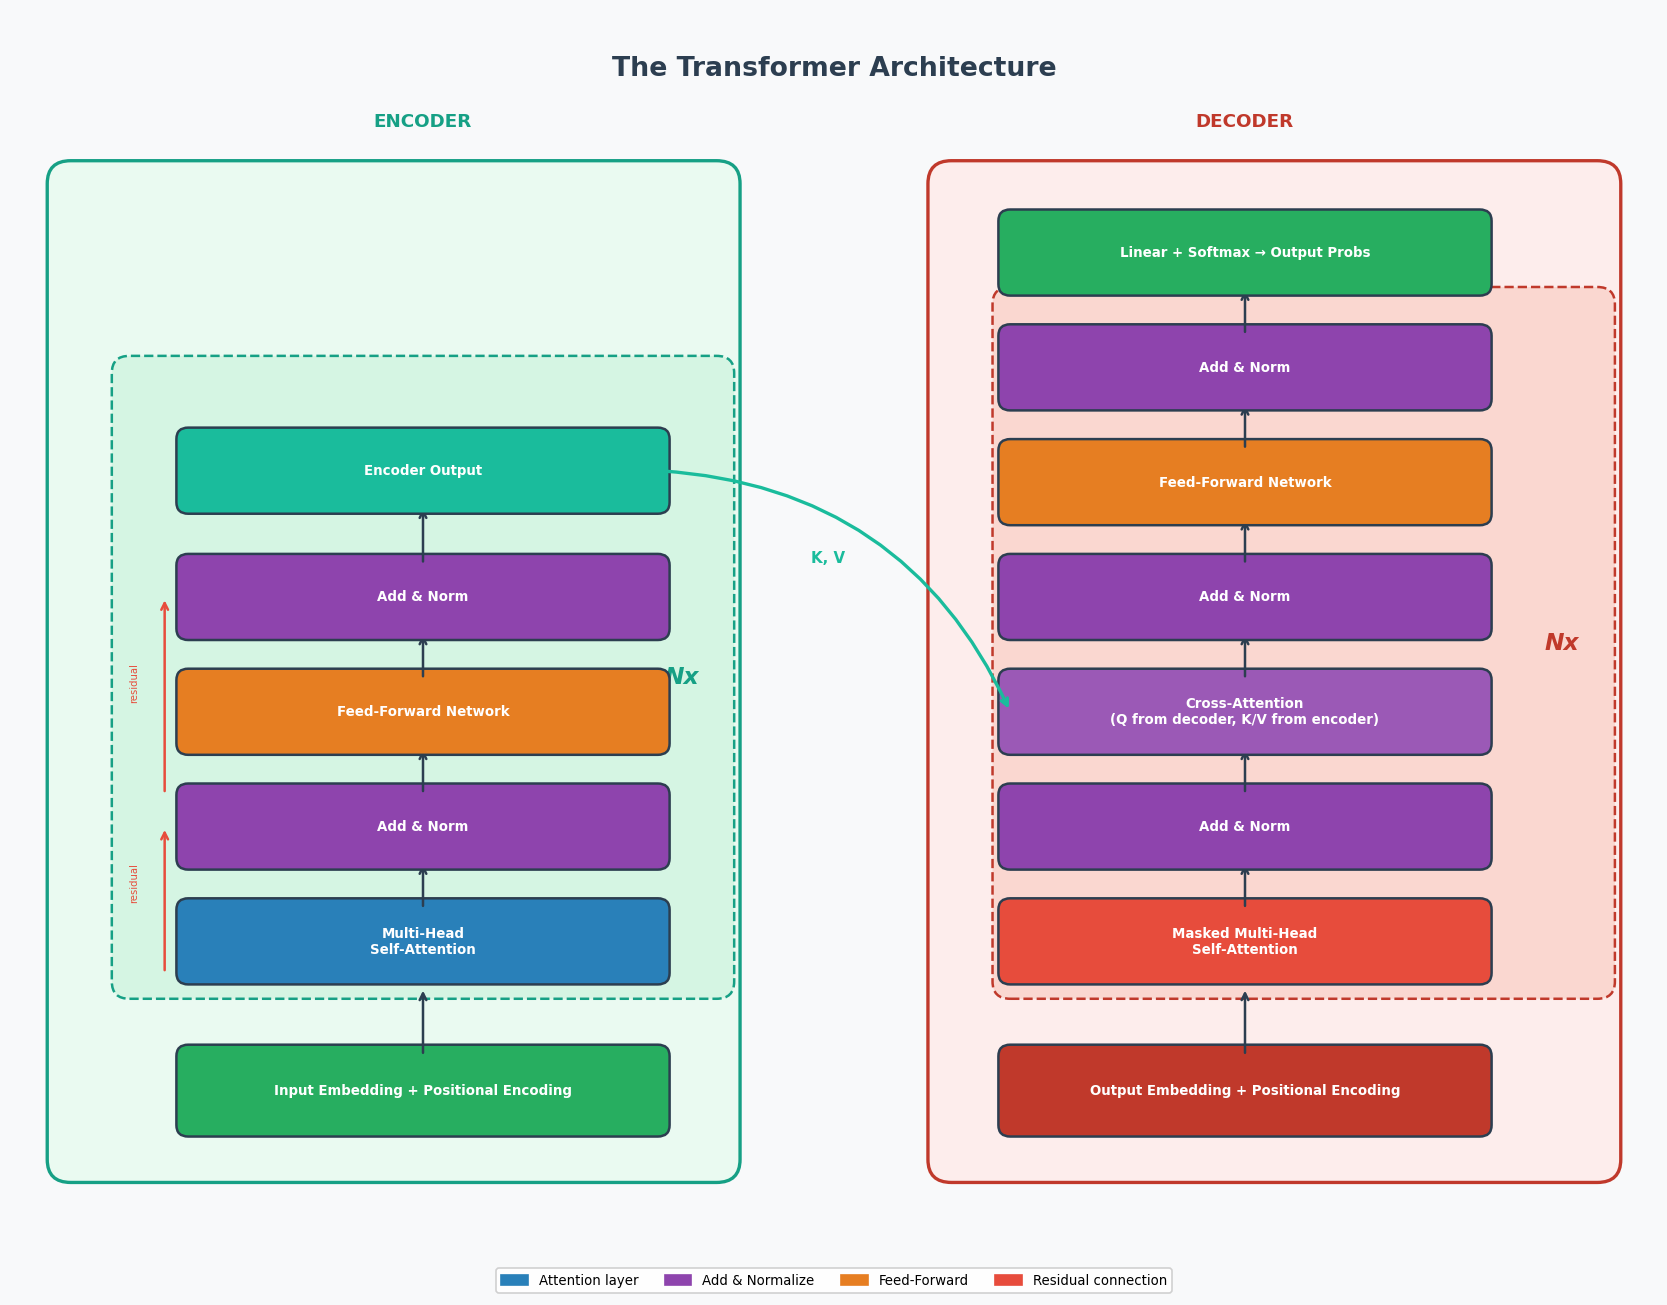

Diagram saved as transformer_architecture.png


In [3]:
# ============================================================
# FIGURE 1: Full Transformer Architecture Diagram
# ============================================================

def draw_box(ax, x, y, w, h, label, color='#4A90D9', fontsize=8, text_color='white', style='round,pad=0.1'):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle=style, linewidth=1.5,
                          edgecolor='#2c3e50', facecolor=color, zorder=3)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=text_color, zorder=4, wrap=True,
            multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2, color='#2c3e50'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

fig, ax = plt.subplots(1, 1, figsize=(14, 11))
ax.set_xlim(0, 14)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

# --- TITLE ---
ax.text(7, 10.5, 'The Transformer Architecture', ha='center', va='center',
        fontsize=16, fontweight='bold', color='#2c3e50')

# --- ENCODER (left side) ---
ax.text(3.5, 10.0, 'ENCODER', ha='center', fontsize=11, fontweight='bold', color='#16a085')

# Encoder stack background
enc_bg = FancyBboxPatch((0.5, 1.0), 5.5, 8.5, boxstyle='round,pad=0.2',
                         linewidth=2, edgecolor='#16a085', facecolor='#eafaf1', zorder=1)
ax.add_patch(enc_bg)

# Encoder components (bottom to top)
draw_box(ax, 3.5, 1.6, 4.0, 0.6, 'Input Embedding + Positional Encoding', '#27ae60', 8)
draw_arrow(ax, 3.5, 1.9, 3.5, 2.5)

# Encoder layer (repeated Nx)
enc_layer_bg = FancyBboxPatch((1.0, 2.55), 5.0, 5.3, boxstyle='round,pad=0.15',
                               linewidth=1.5, edgecolor='#16a085', facecolor='#d5f5e3',
                               linestyle='--', zorder=2)
ax.add_patch(enc_layer_bg)
ax.text(5.7, 5.2, 'Nx', ha='center', va='center', fontsize=14,
        fontweight='bold', color='#16a085', style='italic')

draw_box(ax, 3.5, 2.9, 4.0, 0.55, 'Multi-Head\nSelf-Attention', '#2980b9', 8)
draw_arrow(ax, 3.5, 3.18, 3.5, 3.6)
draw_box(ax, 3.5, 3.9, 4.0, 0.55, 'Add & Norm', '#8e44ad', 8)
draw_arrow(ax, 3.5, 4.18, 3.5, 4.6)
draw_box(ax, 3.5, 4.9, 4.0, 0.55, 'Feed-Forward Network', '#e67e22', 8)
draw_arrow(ax, 3.5, 5.18, 3.5, 5.6)
draw_box(ax, 3.5, 5.9, 4.0, 0.55, 'Add & Norm', '#8e44ad', 8)

# Residual connections for encoder
ax.annotate('', xy=(1.3, 3.9), xytext=(1.3, 2.62),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5, connectionstyle='arc3,rad=0'))
ax.text(1.0, 3.26, 'residual', fontsize=6, color='#e74c3c', rotation=90)
ax.annotate('', xy=(1.3, 5.9), xytext=(1.3, 4.18),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))
ax.text(1.0, 5.0, 'residual', fontsize=6, color='#e74c3c', rotation=90)

draw_arrow(ax, 3.5, 6.18, 3.5, 6.7)
draw_box(ax, 3.5, 7.0, 4.0, 0.55, 'Encoder Output', '#1abc9c', 8)

# --- DECODER (right side) ---
ax.text(10.5, 10.0, 'DECODER', ha='center', fontsize=11, fontweight='bold', color='#c0392b')

# Decoder stack background
dec_bg = FancyBboxPatch((8.0, 1.0), 5.5, 8.5, boxstyle='round,pad=0.2',
                         linewidth=2, edgecolor='#c0392b', facecolor='#fdedec', zorder=1)
ax.add_patch(dec_bg)

# Decoder components (bottom to top)
draw_box(ax, 10.5, 1.6, 4.0, 0.6, 'Output Embedding + Positional Encoding', '#c0392b', 8)
draw_arrow(ax, 10.5, 1.9, 10.5, 2.5)

dec_layer_bg = FancyBboxPatch((8.5, 2.55), 5.0, 5.9, boxstyle='round,pad=0.15',
                               linewidth=1.5, edgecolor='#c0392b', facecolor='#fad7d0',
                               linestyle='--', zorder=2)
ax.add_patch(dec_layer_bg)
ax.text(13.2, 5.5, 'Nx', ha='center', va='center', fontsize=14,
        fontweight='bold', color='#c0392b', style='italic')

draw_box(ax, 10.5, 2.9, 4.0, 0.55, 'Masked Multi-Head\nSelf-Attention', '#e74c3c', 8)
draw_arrow(ax, 10.5, 3.18, 10.5, 3.6)
draw_box(ax, 10.5, 3.9, 4.0, 0.55, 'Add & Norm', '#8e44ad', 8)
draw_arrow(ax, 10.5, 4.18, 10.5, 4.6)
draw_box(ax, 10.5, 4.9, 4.0, 0.55, 'Cross-Attention\n(Q from decoder, K/V from encoder)', '#9b59b6', 8)
draw_arrow(ax, 10.5, 5.18, 10.5, 5.6)
draw_box(ax, 10.5, 5.9, 4.0, 0.55, 'Add & Norm', '#8e44ad', 8)
draw_arrow(ax, 10.5, 6.18, 10.5, 6.6)
draw_box(ax, 10.5, 6.9, 4.0, 0.55, 'Feed-Forward Network', '#e67e22', 8)
draw_arrow(ax, 10.5, 7.18, 10.5, 7.6)
draw_box(ax, 10.5, 7.9, 4.0, 0.55, 'Add & Norm', '#8e44ad', 8)
draw_arrow(ax, 10.5, 8.18, 10.5, 8.6)
draw_box(ax, 10.5, 8.9, 4.0, 0.55, 'Linear + Softmax → Output Probs', '#27ae60', 8)

# Cross-attention arrow (encoder → decoder)
ax.annotate('', xy=(8.5, 4.9), xytext=(5.5, 7.0),
            arrowprops=dict(arrowstyle='->', color='#1abc9c', lw=2.0,
                            connectionstyle='arc3,rad=-0.3'))
ax.text(6.8, 6.2, 'K, V', fontsize=9, color='#1abc9c', fontweight='bold')

# Legend
legend_items = [
    mpatches.Patch(color='#2980b9', label='Attention layer'),
    mpatches.Patch(color='#8e44ad', label='Add & Normalize'),
    mpatches.Patch(color='#e67e22', label='Feed-Forward'),
    mpatches.Patch(color='#e74c3c', label='Residual connection'),
]
ax.legend(handles=legend_items, loc='upper center', bbox_to_anchor=(0.5, 0.01),
          ncol=4, fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('transformer_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Diagram saved as transformer_architecture.png')

---
## Chapter 2: Positional Encoding — Teaching the Model About Order

### The Problem
Unlike RNNs, transformers process all tokens **at once** (in parallel). This means they have **no built-in sense of order**. "The cat sat" and "sat cat The" would look identical to a vanilla transformer!

### The Solution: Positional Encoding
We add a **position signal** to each word embedding — a unique "fingerprint" for each position in the sequence.

### The Formula
For position `pos` and dimension `i`:

$$PE_{(pos,\, 2i)} = \sin\!\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$

$$PE_{(pos,\, 2i+1)} = \cos\!\left(\frac{pos}{10000^{\frac{2i}{d_{model}}}}\right)$$

### Why sin/cos?
1. **Unique per position**: Each position gets a unique pattern
2. **Relative positions learnable**: `PE[pos+k]` can be expressed as a linear function of `PE[pos]`
3. **Works for unseen lengths**: The pattern generalizes beyond training sequence lengths
4. **Bounded**: Values always between -1 and 1 — won't destabilize training

**Simple analogy**: Think of it like a clock — hours, minutes, and seconds all use periodic signals to encode time. Different frequencies encode different "scales" of position.

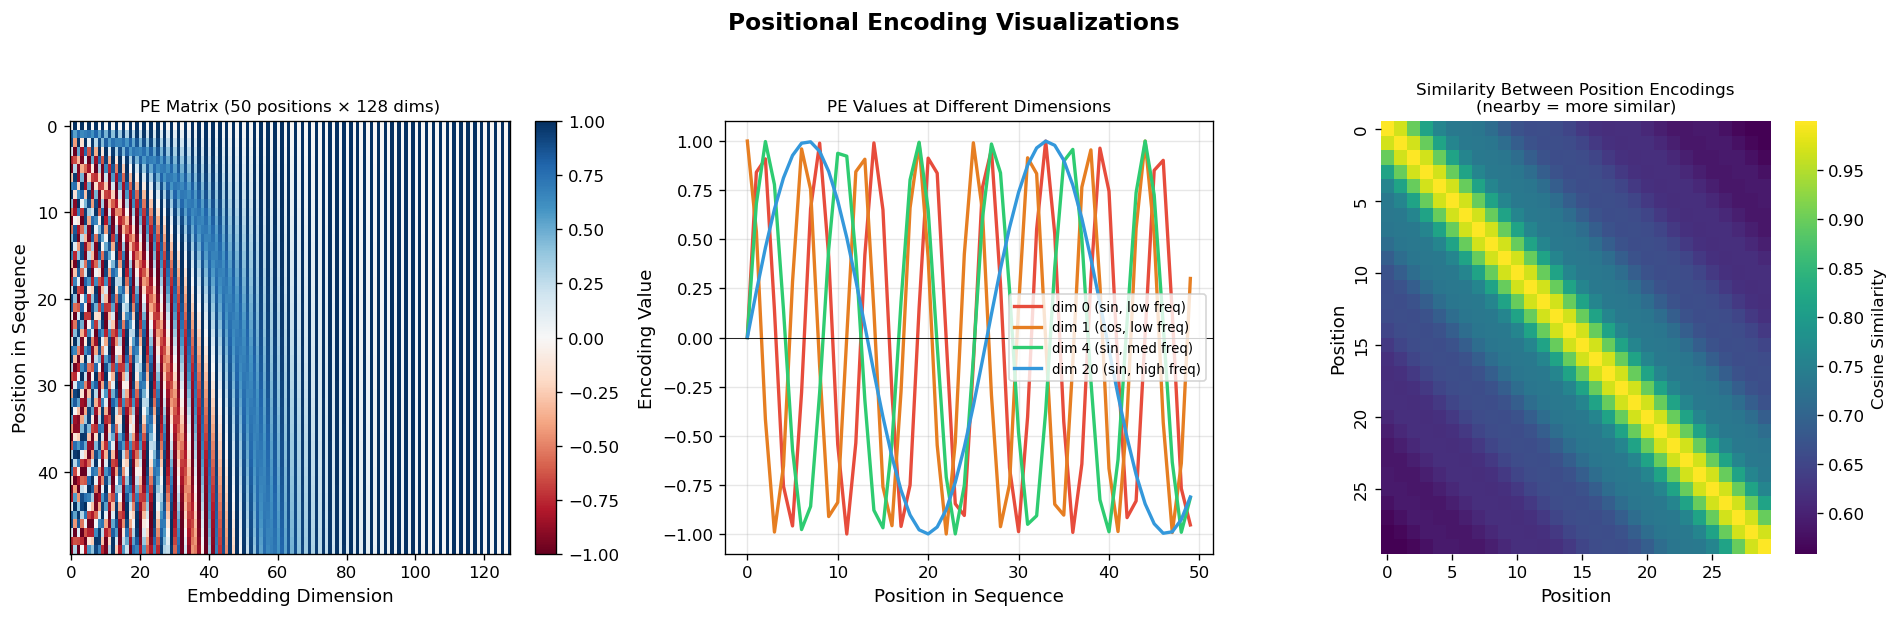

✅ Key insight: Nearby positions have high cosine similarity,
   meaning the model can infer relative distance from PE vectors!


In [4]:
# ============================================================
# FIGURE 2: Positional Encoding Visualization
# ============================================================

def get_positional_encoding(max_seq_len, d_model):
    pe = np.zeros((max_seq_len, d_model))
    for pos in range(max_seq_len):
        for i in range(0, d_model, 2):
            angle = pos / (10000 ** (i / d_model))
            pe[pos, i] = np.sin(angle)
            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(angle)
    return pe

pe = get_positional_encoding(50, 128)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Positional Encoding Visualizations', fontsize=14, fontweight='bold', y=1.02)

# Plot 1: Full heatmap
ax = axes[0]
im = ax.imshow(pe, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel('Embedding Dimension', fontsize=11)
ax.set_ylabel('Position in Sequence', fontsize=11)
ax.set_title('PE Matrix (50 positions × 128 dims)', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046)

# Plot 2: Frequency comparison — different dimensions
ax = axes[1]
positions = np.arange(50)
for dim, color, label in [(0, '#e74c3c', 'dim 0 (sin, low freq)'),
                            (1, '#e67e22', 'dim 1 (cos, low freq)'),
                            (4, '#2ecc71', 'dim 4 (sin, med freq)'),
                            (20, '#3498db', 'dim 20 (sin, high freq)')]:
    ax.plot(positions, pe[:, dim], color=color, linewidth=2, label=label)
ax.set_xlabel('Position in Sequence', fontsize=11)
ax.set_ylabel('Encoding Value', fontsize=11)
ax.set_title('PE Values at Different Dimensions', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

# Plot 3: Similarity between positions
ax = axes[2]
similarity = pe[:30] @ pe[:30].T
norms = np.linalg.norm(pe[:30], axis=1, keepdims=True)
cosine_sim = similarity / (norms @ norms.T + 1e-8)
sns.heatmap(cosine_sim, ax=ax, cmap='viridis', xticklabels=5, yticklabels=5,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_xlabel('Position', fontsize=11)
ax.set_ylabel('Position', fontsize=11)
ax.set_title('Similarity Between Position Encodings\n(nearby = more similar)', fontsize=10)

plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Key insight: Nearby positions have high cosine similarity,')
print('   meaning the model can infer relative distance from PE vectors!')

---
## Chapter 3: The Attention Mechanism — The Heart of the Transformer

### The Core Idea
**Attention** answers: *"When processing word X, how much should I focus on each other word?"*

### The Query, Key, Value Framework

Think of it like a **library search system**:

| Component | Library Analogy | In Transformers |
|-----------|-----------------|------------------|
| **Query (Q)** | Your search query | What the current token is "looking for" |
| **Key (K)** | Book title/index | What each token "advertises" about itself |
| **Value (V)** | The actual book content | The actual information a token carries |

**Process:**
1. Your query (`Q`) is matched against all keys (`K`) → gives **relevance scores**
2. Scores are softmaxed → **attention weights** (sum to 1)
3. Weights applied to values (`V`) → **weighted sum = attended output**

### The Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Why divide by √d_k?**  
With large d_k, dot products grow large → softmax gets "peaky" → gradients vanish.  
Dividing by √d_k keeps the variance of scores ≈ 1 regardless of dimension size.

### Where do Q, K, V come from?
Each is a **learned linear projection** of the input:
$$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$$
where $W_Q, W_K, W_V$ are learned weight matrices.

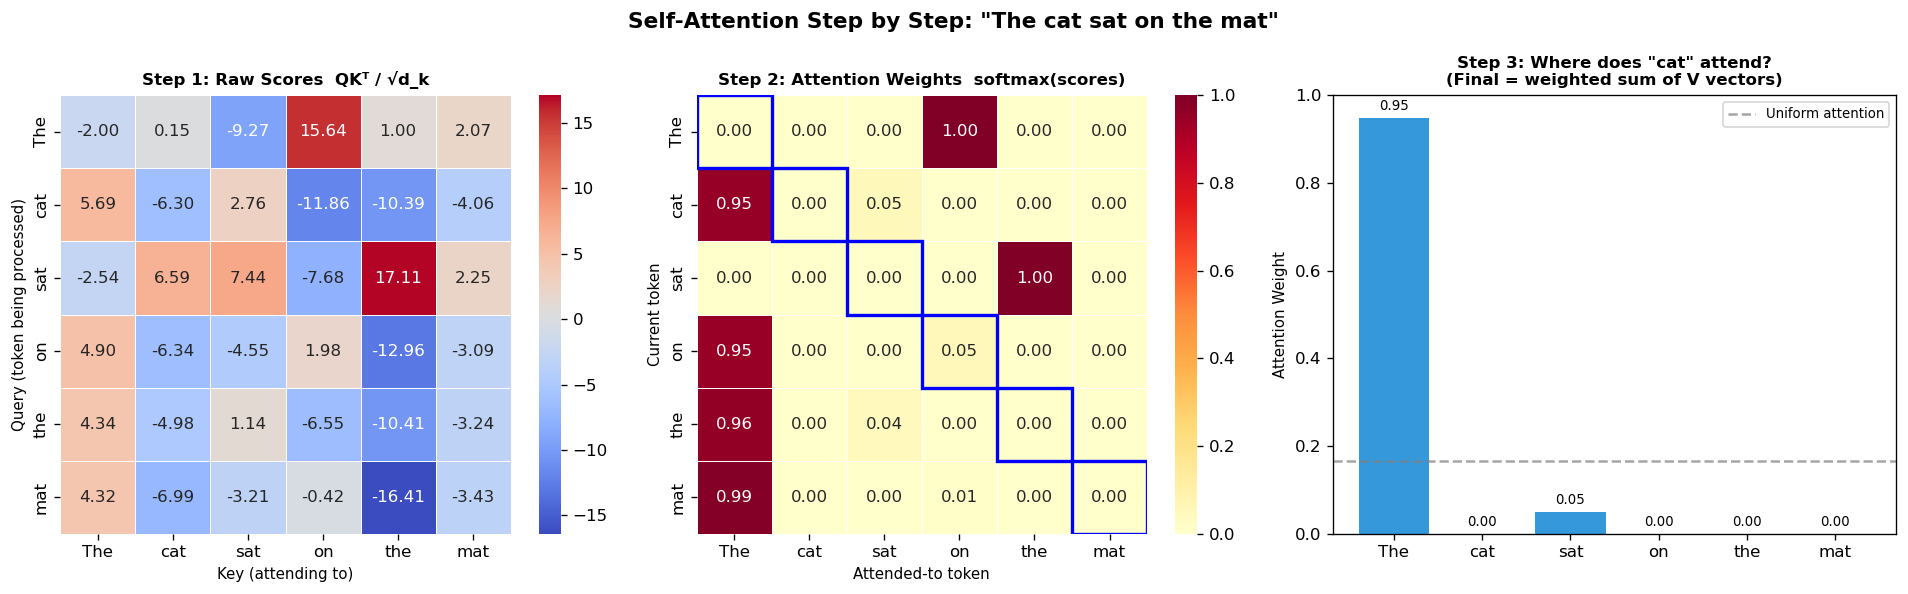


📊 Row sums (should all = 1.0): [1. 1. 1. 1. 1. 1.]
✅ Each token attends to ALL other tokens — a weighted mixture of their Values


In [5]:
# ============================================================
# FIGURE 3: Step-by-step Attention Walkthrough
# ============================================================

# Example sentence: "The cat sat on the mat"
words = ['The', 'cat', 'sat', 'on', 'the', 'mat']
n = len(words)
d_k = 4  # small for illustration

np.random.seed(42)

# Simulate learned projections
d_model = 8
X = np.random.randn(n, d_model)   # word embeddings
Wq = np.random.randn(d_model, d_k)
Wk = np.random.randn(d_model, d_k)
Wv = np.random.randn(d_model, d_k)

Q = X @ Wq  # (6, 4)
K = X @ Wk  # (6, 4)
V = X @ Wv  # (6, 4)

# Compute attention scores
scores = Q @ K.T / np.sqrt(d_k)   # (6, 6)
attention_weights = np.exp(scores) / np.exp(scores).sum(axis=-1, keepdims=True)
output = attention_weights @ V    # (6, 4)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Self-Attention Step by Step: "The cat sat on the mat"',
             fontsize=13, fontweight='bold')

# Plot 1: Raw scores
ax = axes[0]
sns.heatmap(scores, annot=True, fmt='.2f', ax=ax, cmap='coolwarm',
            xticklabels=words, yticklabels=words, linewidths=0.5)
ax.set_title('Step 1: Raw Scores  QKᵀ / √d_k', fontsize=10, fontweight='bold')
ax.set_xlabel('Key (attending to)', fontsize=9)
ax.set_ylabel('Query (token being processed)', fontsize=9)

# Plot 2: Attention weights (after softmax)
ax = axes[1]
sns.heatmap(attention_weights, annot=True, fmt='.2f', ax=ax, cmap='YlOrRd',
            xticklabels=words, yticklabels=words, linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Step 2: Attention Weights  softmax(scores)', fontsize=10, fontweight='bold')
ax.set_xlabel('Attended-to token', fontsize=9)
ax.set_ylabel('Current token', fontsize=9)
for i in range(n):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False, edgecolor='blue', lw=2))

# Plot 3: Which token attends most to which?
ax = axes[2]
focus_token = 1  # 'cat'
bar_colors = [f'#{int(255*w):02x}{int(100*(1-w)):02x}30' for w in attention_weights[focus_token]]
bars = ax.bar(words, attention_weights[focus_token], color=['#e74c3c' if i == focus_token else '#3498db' for i in range(n)])
ax.set_title(f'Step 3: Where does "{words[focus_token]}" attend?\n(Final = weighted sum of V vectors)', fontsize=10, fontweight='bold')
ax.set_ylabel('Attention Weight', fontsize=9)
ax.set_ylim(0, 1)
for bar, val in zip(bars, attention_weights[focus_token]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)
ax.axhline(y=1/n, color='gray', linestyle='--', alpha=0.7, label='Uniform attention')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('attention_mechanism.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Row sums (should all = 1.0):', np.round(attention_weights.sum(axis=1), 4))
print(f'✅ Each token attends to ALL other tokens — a weighted mixture of their Values')

---
## Chapter 4: Multi-Head Attention — Learning Multiple Relationships

### The Limitation of Single-Head Attention

A single attention head learns **one type** of relationship at a time. But language has many simultaneous relationships:
- **Syntactic**: subject-verb agreement
- **Semantic**: word meaning
- **Coreference**: pronoun resolution ("it" → "cat")
- **Long-range**: distant dependencies

### Multi-Head Attention: Run h Attention Heads in Parallel

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)\, W^O$$

where each head is:
$$\text{head}_i = \text{Attention}(QW_i^Q,\; KW_i^K,\; VW_i^V)$$

**Key insight:** Each head gets its own learned projections `W_i^Q, W_i^K, W_i^V` so it can specialize in different relationship types. The outputs are concatenated and projected back to `d_model`.

**Dimension management:**
- Model dimension: `d_model = 512`
- Number of heads: `h = 8`  
- Each head dimension: `d_k = d_model / h = 64`
- Total computation ≈ same as single head at full dimension!

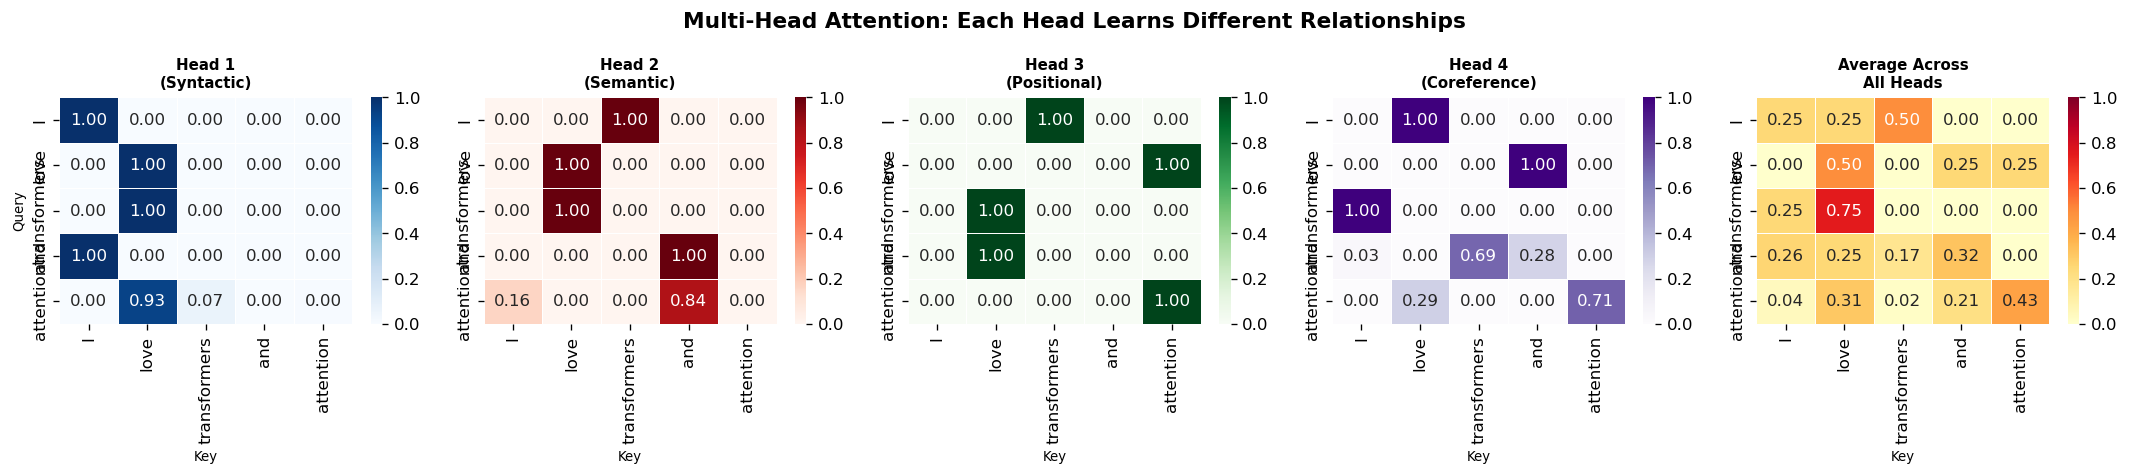

✅ Each head has learned to attend to DIFFERENT patterns!
   The final output concatenates all heads, capturing all relationship types.


In [6]:
# ============================================================
# FIGURE 4: Multi-Head Attention — heads specializing
# ============================================================

np.random.seed(0)
num_heads = 4
words = ['I', 'love', 'transformers', 'and', 'attention']
n = len(words)
d_model = 16
d_k = d_model // num_heads  # 4 per head

X = np.random.randn(n, d_model)

fig, axes = plt.subplots(1, num_heads + 1, figsize=(18, 4))
fig.suptitle('Multi-Head Attention: Each Head Learns Different Relationships',
             fontsize=13, fontweight='bold')

head_colors = ['Blues', 'Reds', 'Greens', 'Purples']
head_names = ['Head 1\n(Syntactic)', 'Head 2\n(Semantic)', 'Head 3\n(Positional)', 'Head 4\n(Coreference)']

all_weights = []
for h in range(num_heads):
    np.random.seed(h * 10 + 7)
    Wq_h = np.random.randn(d_model, d_k)
    Wk_h = np.random.randn(d_model, d_k)
    Q_h = X @ Wq_h
    K_h = X @ Wk_h
    scores_h = Q_h @ K_h.T / np.sqrt(d_k)
    # Add bias so heads "specialize" differently
    bias = np.eye(n) * (h - 1.5) * 2
    scores_h = scores_h + bias
    w_h = np.exp(scores_h) / np.exp(scores_h).sum(axis=-1, keepdims=True)
    all_weights.append(w_h)

    ax = axes[h]
    sns.heatmap(w_h, annot=True, fmt='.2f', ax=ax, cmap=head_colors[h],
                xticklabels=words, yticklabels=words, linewidths=0.5, vmin=0, vmax=1)
    ax.set_title(head_names[h], fontsize=9, fontweight='bold')
    ax.set_xlabel('Key', fontsize=8)
    if h == 0:
        ax.set_ylabel('Query', fontsize=8)

# Average attention (combined effect)
avg_weights = np.mean(all_weights, axis=0)
ax = axes[num_heads]
sns.heatmap(avg_weights, annot=True, fmt='.2f', ax=ax, cmap='YlOrRd',
            xticklabels=words, yticklabels=words, linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Average Across\nAll Heads', fontsize=9, fontweight='bold')
ax.set_xlabel('Key', fontsize=8)

plt.tight_layout()
plt.savefig('multihead_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Each head has learned to attend to DIFFERENT patterns!')
print('   The final output concatenates all heads, capturing all relationship types.')

---
## Chapter 5: TensorFlow / Keras Implementation — From Scratch

Now let's build a complete transformer in TensorFlow/Keras.
Every component maps directly to the architecture diagram above.


In [ ]:
# ============================================================
# TENSORFLOW / KERAS TRANSFORMER — COMPLETE FROM SCRATCH
# ============================================================

# ------------------------------------------------------------------
# 1. Scaled Dot-Product Attention
# ------------------------------------------------------------------
def scaled_dot_product_attention(q, k, v, attn_mask=None):
    """
    q, k, v   : (batch, heads, seq_len, depth)
    attn_mask : (1, 1, seq_q, seq_k) float32 — 1 = ignore, 0 = attend
    Returns   : output (same shape as v), attention_weights
    """
    d_k    = tf.cast(tf.shape(q)[-1], tf.float32)
    scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(d_k)
    if attn_mask is not None:
        scores += tf.cast(attn_mask, tf.float32) * -1e9
    weights = tf.nn.softmax(scores, axis=-1)
    return tf.matmul(weights, v), weights


# ------------------------------------------------------------------
# 2. Multi-Head Attention
# ------------------------------------------------------------------
class MultiHeadAttention(keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.num_heads = num_heads
        self.d_model   = d_model
        self.depth     = d_model // num_heads

        self.Wq = keras.layers.Dense(d_model, use_bias=False, name='Wq')
        self.Wk = keras.layers.Dense(d_model, use_bias=False, name='Wk')
        self.Wv = keras.layers.Dense(d_model, use_bias=False, name='Wv')
        self.Wo = keras.layers.Dense(d_model, name='Wo')

    def split_heads(self, x):
        """(batch, seq, d_model) → (batch, heads, seq, depth)"""
        batch = tf.shape(x)[0]
        seq   = tf.shape(x)[1]
        x = tf.reshape(x, tf.stack([batch, seq, self.num_heads, self.depth]))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    # NOTE: parameter renamed to 'attn_mask' to avoid collision with
    # Keras's built-in 'mask' propagation argument.
    def call(self, query, key, value, attn_mask=None, training=False):
        q = self.split_heads(self.Wq(query))
        k = self.split_heads(self.Wk(key))
        v = self.split_heads(self.Wv(value))

        x, attn_weights = scaled_dot_product_attention(q, k, v, attn_mask)

        batch = tf.shape(x)[0]
        seq   = tf.shape(x)[2]
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        x = tf.reshape(x, tf.stack([batch, seq, self.d_model]))
        return self.Wo(x), attn_weights


# ------------------------------------------------------------------
# 3. Positional Encoding
# ------------------------------------------------------------------
class PositionalEncoding(keras.layers.Layer):
    def __init__(self, d_model, max_len=5000, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dropout = keras.layers.Dropout(dropout)

        positions = np.arange(max_len)[:, np.newaxis]
        dims      = np.arange(0, d_model, 2)[np.newaxis, :]
        angles    = positions / np.power(10000.0, dims / d_model)

        pe = np.zeros((1, max_len, d_model), dtype=np.float32)
        pe[0, :, 0::2] = np.sin(angles)
        pe[0, :, 1::2] = np.cos(angles)
        self.pe = tf.constant(pe, dtype=tf.float32)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x, training=training)


# ------------------------------------------------------------------
# 4. Position-wise Feed-Forward Network
# ------------------------------------------------------------------
class FeedForward(keras.layers.Layer):
    def __init__(self, d_model, d_ff, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.dense1  = keras.layers.Dense(d_ff, activation='relu')
        self.dense2  = keras.layers.Dense(d_model)
        self.dropout = keras.layers.Dropout(dropout)

    def call(self, x, training=False):
        return self.dense2(self.dropout(self.dense1(x), training=training))


# ------------------------------------------------------------------
# 5. Encoder Layer
# ------------------------------------------------------------------
class EncoderLayer(keras.layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ff        = FeedForward(d_model, d_ff, dropout)
        self.norm1     = keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2     = keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1     = keras.layers.Dropout(dropout)
        self.drop2     = keras.layers.Dropout(dropout)

    # 'attn_mask' instead of 'mask' — avoids Keras built-in mask injection
    def call(self, x, attn_mask=None, training=False):
        attn_out, _ = self.self_attn(x, x, x, attn_mask=attn_mask)
        x = self.norm1(x + self.drop1(attn_out, training=training))
        ff_out = self.ff(x, training=training)
        x = self.norm2(x + self.drop2(ff_out,   training=training))
        return x


# ------------------------------------------------------------------
# 6. Decoder Layer
# ------------------------------------------------------------------
class DecoderLayer(keras.layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.self_attn  = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ff         = FeedForward(d_model, d_ff, dropout)
        self.norm1      = keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2      = keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm3      = keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1      = keras.layers.Dropout(dropout)
        self.drop2      = keras.layers.Dropout(dropout)
        self.drop3      = keras.layers.Dropout(dropout)

    def call(self, x, enc_output, src_attn_mask=None, tgt_attn_mask=None, training=False):
        sa_out, _      = self.self_attn(x, x, x,
                                        attn_mask=tgt_attn_mask)
        x = self.norm1(x + self.drop1(sa_out, training=training))
        ca_out, attn_w = self.cross_attn(x, enc_output, enc_output,
                                         attn_mask=src_attn_mask)
        x = self.norm2(x + self.drop2(ca_out, training=training))
        ff_out = self.ff(x, training=training)
        x = self.norm3(x + self.drop3(ff_out, training=training))
        return x, attn_w


# ------------------------------------------------------------------
# 7. Full Transformer
# ------------------------------------------------------------------
class Transformer(keras.Model):
    def __init__(self, src_vocab, tgt_vocab, d_model=512, num_heads=8,
                 num_enc_layers=6, num_dec_layers=6, d_ff=2048,
                 max_seq_len=512, dropout=0.1):
        super().__init__()
        self.d_model   = d_model
        self.scale     = tf.math.sqrt(tf.cast(d_model, tf.float32))
        self.src_embed = keras.layers.Embedding(src_vocab, d_model)
        self.tgt_embed = keras.layers.Embedding(tgt_vocab, d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_seq_len, dropout)
        self.enc_layers = [EncoderLayer(d_model, num_heads, d_ff, dropout,
                                        name=f'enc_{i}')
                           for i in range(num_enc_layers)]
        self.dec_layers = [DecoderLayer(d_model, num_heads, d_ff, dropout,
                                        name=f'dec_{i}')
                           for i in range(num_dec_layers)]
        self.out_proj  = keras.layers.Dense(tgt_vocab, name='output_projection')
        self.drop      = keras.layers.Dropout(dropout)

    @staticmethod
    def make_causal_mask(size):
        """Upper-triangular mask: 1.0 = future (ignore), 0.0 = past (attend)."""
        idx  = tf.range(size)
        mask = tf.cast(idx[tf.newaxis, :] > idx[:, tf.newaxis], tf.float32)
        return mask[tf.newaxis, tf.newaxis, :, :]   # (1, 1, size, size)

    def encode(self, src, src_attn_mask=None, training=False):
        x = self.pos_enc(self.src_embed(src) * self.scale, training=training)
        for layer in self.enc_layers:
            x = layer(x, attn_mask=src_attn_mask, training=training)
        return x

    def decode(self, tgt, enc_output, src_attn_mask=None, tgt_attn_mask=None, training=False):
        x = self.pos_enc(self.tgt_embed(tgt) * self.scale, training=training)
        attn_weights = []
        for layer in self.dec_layers:
            x, attn_w = layer(x, enc_output,
                              src_attn_mask=src_attn_mask,
                              tgt_attn_mask=tgt_attn_mask,
                              training=training)
            attn_weights.append(attn_w)
        return x, attn_weights

    def call(self, inputs, training=False):
        src, tgt     = inputs
        tgt_attn_mask = self.make_causal_mask(tf.shape(tgt)[1])
        enc_out       = self.encode(src, training=training)
        dec_out, attn_weights = self.decode(tgt, enc_out,
                                             tgt_attn_mask=tgt_attn_mask,
                                             training=training)
        logits = self.out_proj(dec_out)
        self.last_attn_weights = attn_weights   # inspect after forward pass
        return logits


# ------------------------------------------------------------------
# Smoke test
# ------------------------------------------------------------------
print('Building Transformer...')
model = Transformer(src_vocab=1000, tgt_vocab=1000, d_model=128,
                    num_heads=4, num_enc_layers=2, num_dec_layers=2, d_ff=256)

src = tf.random.uniform((2, 10), minval=0, maxval=1000, dtype=tf.int32)
tgt = tf.random.uniform((2,  8), minval=0, maxval=1000, dtype=tf.int32)

logits = model((src, tgt), training=False)
attn   = model.last_attn_weights

print(f'\n✅ Transformer built successfully!')
print(f'   Input  shape : {src.shape}   (batch, src_seq_len)')
print(f'   Target shape : {tgt.shape}    (batch, tgt_seq_len)')
print(f'   Output shape : {logits.shape}  (batch, tgt_seq_len, vocab_size)')
print(f'   Attn layers  : {len(attn)} decoder cross-attention tensors')
print(f'   Total params : {model.count_params():,}')

---
## Chapter 6: Connect to Any LLM

Now that you understand how transformers work internally, let's connect to production LLMs.  
We support **Anthropic Claude**, **OpenAI GPT**, **HuggingFace**, and **Ollama** (local, free).


In [ ]:
# ============================================================
# LLM CONNECTOR — A unified interface for any LLM
# ============================================================

import os
import json
from typing import Optional

class LLMConnector:
    """
    Unified interface to talk to:
      - Anthropic Claude  (provider='anthropic')
      - OpenAI GPT        (provider='openai')
      - HuggingFace Hub   (provider='huggingface')
      - Ollama (local)    (provider='ollama')
    """

    MODELS = {
        'anthropic':   'claude-sonnet-4-6',
        'openai':      'gpt-4o',
        'huggingface': 'mistralai/Mixtral-8x7B-Instruct-v0.1',
        'ollama':      'llama3',
    }

    def __init__(self, provider: str = 'anthropic',
                 api_key: Optional[str] = None,
                 model: Optional[str] = None):
        self.provider = provider.lower()
        self.model    = model or self.MODELS.get(self.provider, 'unknown')
        self.api_key  = api_key or os.environ.get(self._env_var())

    def _env_var(self):
        return {'anthropic': 'ANTHROPIC_API_KEY',
                'openai':    'OPENAI_API_KEY',
                'huggingface': 'HUGGINGFACE_API_KEY'}.get(self.provider, '')

    def chat(self, message: str, system: str = '', max_tokens: int = 1024) -> str:
        if self.provider == 'anthropic':
            return self._chat_anthropic(message, system, max_tokens)
        elif self.provider == 'openai':
            return self._chat_openai(message, system, max_tokens)
        elif self.provider == 'huggingface':
            return self._chat_huggingface(message, max_tokens)
        elif self.provider == 'ollama':
            return self._chat_ollama(message, system, max_tokens)
        else:
            raise ValueError(f'Unknown provider: {self.provider}')

    def _chat_anthropic(self, message, system, max_tokens):
        import anthropic
        client = anthropic.Anthropic(api_key=self.api_key)
        kwargs = dict(model=self.model, max_tokens=max_tokens,
                      messages=[{'role': 'user', 'content': message}])
        if system:
            kwargs['system'] = system
        response = client.messages.create(**kwargs)
        return response.content[0].text

    def _chat_openai(self, message, system, max_tokens):
        from openai import OpenAI
        client = OpenAI(api_key=self.api_key)
        messages = []
        if system:
            messages.append({'role': 'system', 'content': system})
        messages.append({'role': 'user', 'content': message})
        response = client.chat.completions.create(
            model=self.model, messages=messages, max_tokens=max_tokens)
        return response.choices[0].message.content

    def _chat_huggingface(self, message, max_tokens):
        import requests
        headers = {'Authorization': f'Bearer {self.api_key}'}
        url = f'https://api-inference.huggingface.co/models/{self.model}'
        payload = {'inputs': message,
                   'parameters': {'max_new_tokens': max_tokens, 'return_full_text': False}}
        resp = requests.post(url, headers=headers, json=payload)
        resp.raise_for_status()
        return resp.json()[0]['generated_text']

    def _chat_ollama(self, message, system, max_tokens):
        import requests
        payload = {
            'model': self.model,
            'messages': [
                *([{'role': 'system', 'content': system}] if system else []),
                {'role': 'user', 'content': message}
            ],
            'stream': False,
            'options': {'num_predict': max_tokens}
        }
        resp = requests.post('http://localhost:11434/api/chat', json=payload)
        resp.raise_for_status()
        return resp.json()['message']['content']

    def __repr__(self):
        return f'LLMConnector(provider={self.provider!r}, model={self.model!r})'


# ---- USAGE EXAMPLES ---- (uncomment one and run)

PROMPT = 'In one sentence, what is the key insight behind attention in transformers?'

# Option 1: Anthropic Claude (set ANTHROPIC_API_KEY env var)
# claude = LLMConnector('anthropic')
# print(claude.chat(PROMPT, system='You are a machine learning expert.'))

# Option 2: OpenAI GPT (set OPENAI_API_KEY env var)
# gpt = LLMConnector('openai')
# print(gpt.chat(PROMPT))

# Option 3: Ollama — FREE, runs locally (install from ollama.com, then: ollama pull llama3)
# ollama = LLMConnector('ollama', model='llama3')
# print(ollama.chat(PROMPT))

# Option 4: HuggingFace Inference API (set HUGGINGFACE_API_KEY)
# hf = LLMConnector('huggingface', model='mistralai/Mistral-7B-Instruct-v0.1')
# print(hf.chat(PROMPT))

print('LLMConnector class ready!')
print('Supported providers:', list(LLMConnector.MODELS.keys()))
print()
print('USAGE:')
print("  llm = LLMConnector('anthropic', api_key='YOUR_KEY')")
print("  response = llm.chat('Explain self-attention in 2 sentences.')")
print("  print(response)")

---
## Chapter 7: Audio Explanations

Listen to spoken explanations of key transformer concepts.  
Uses **Google Text-to-Speech (gTTS)** — requires internet access.


In [ ]:
# ============================================================
# AUDIO EXPLANATIONS — Listen to transformer concepts
# ============================================================

from IPython.display import Audio, display
import io

EXPLANATIONS = {
    'transformer_overview': """
        The Transformer is a neural network architecture introduced in 2017 by Google researchers
        in a paper called Attention Is All You Need. Unlike previous models that processed words
        one at a time, the Transformer processes all words simultaneously using a mechanism
        called self-attention. This parallel processing makes it dramatically faster to train
        and allows it to capture long-range relationships in text far more effectively.
        The Transformer is the foundation for all modern large language models, including
        GPT, Claude, Gemini, and LLaMA.
    """,
    'attention': """
        Attention is the core mechanism of the Transformer. It allows each word in a sentence
        to look at every other word and decide how much to focus on each one.
        Think of it like a spotlight. When processing the word "it" in a sentence,
        attention helps the model shine its spotlight more brightly on "cat" than on
        other words, resolving what "it" refers to.
        Mathematically, attention uses three matrices called Query, Key, and Value.
        The Query represents what we are looking for. The Key represents what each word
        offers. Their dot product gives relevance scores, which are normalized and used
        to weight the Values, producing a context-rich representation.
    """,
    'positional_encoding': """
        Since the Transformer processes all words at once, it has no built-in sense of order.
        Positional Encoding solves this by adding a unique pattern to each word's representation
        based on its position in the sequence.
        These patterns use sine and cosine functions at different frequencies,
        like a clock using hours, minutes, and seconds to encode time.
        Nearby positions get similar patterns, so the model can infer relative distance.
        The patterns are bounded between minus one and one, keeping training stable.
    """,
    'multi_head_attention': """
        Multi-Head Attention runs several attention operations in parallel, called heads.
        Each head can learn to focus on a different type of relationship.
        For example, one head might specialize in grammatical subject-verb agreement,
        another in resolving pronouns, and another in long-range semantic relationships.
        The outputs of all heads are concatenated and projected back to the original
        dimension. This allows the model to simultaneously understand multiple
        aspects of how words relate to each other.
    """,
    'encoder_decoder': """
        The original Transformer has two main components: an Encoder and a Decoder.
        The Encoder reads the input sequence, such as a sentence in French,
        and creates rich contextual representations called memory.
        The Decoder generates the output sequence, such as the English translation,
        one token at a time. It attends to its own previous outputs using masked
        self-attention, and also attends to the Encoder's output using cross-attention.
        Modern models like BERT use only the Encoder, while GPT uses only the Decoder.
        Models like T5 use both.
    """
}


def play_explanation(topic: str):
    """Generate and play an audio explanation for the given topic."""
    if topic not in EXPLANATIONS:
        print(f'Available topics: {list(EXPLANATIONS.keys())}')
        return

    text = ' '.join(EXPLANATIONS[topic].split())  # clean whitespace

    try:
        from gtts import gTTS
        print(f'🔊 Generating audio for: "{topic}"...')
        tts = gTTS(text=text, lang='en', slow=False)
        buf = io.BytesIO()
        tts.write_to_fp(buf)
        buf.seek(0)
        print(f'📖 Text: {text[:120]}...')
        display(Audio(data=buf.read(), format='mp3', autoplay=False))
    except ImportError:
        print('⚠️  gTTS not installed. Run: pip install gtts')
        print(f'\n📖 Transcript ({topic}):\n{text}')
    except Exception as e:
        print(f'⚠️  Audio generation failed ({e}). Showing transcript instead.')
        print(f'\n📖 Transcript:\n{text}')


print('🎧 Audio Explanation System Ready!')
print('\nAvailable topics:')
for t in EXPLANATIONS:
    print(f'  play_explanation("{t}")')
print()
# Play one now:
play_explanation('transformer_overview')

In [ ]:
# Play more topics — uncomment any line below

# play_explanation('attention')
# play_explanation('positional_encoding')
# play_explanation('multi_head_attention')
# play_explanation('encoder_decoder')

---
## Chapter 8: Interactive Demo — Ask an LLM About Transformers

Combine everything: use a real LLM to answer your transformer questions.


In [ ]:
# ============================================================
# INTERACTIVE DEMO: Ask the LLM transformer questions
# ============================================================
# Replace with your actual key, or set env var ANTHROPIC_API_KEY
API_KEY = os.environ.get('ANTHROPIC_API_KEY', 'YOUR_API_KEY_HERE')
PROVIDER = 'anthropic'  # change to 'openai', 'ollama', 'huggingface'

SYSTEM_PROMPT = """
You are an expert machine learning researcher specializing in transformer architectures.
Give concise, technically accurate answers with intuitive analogies where helpful.
Focus on building understanding, not just definitions.
"""

DEMO_QUESTIONS = [
    'Why do we scale attention scores by √d_k before softmax?',
    'What is the difference between encoder-only, decoder-only, and encoder-decoder transformers?',
    'How does masked self-attention in the decoder prevent information leakage?',
    'Why does layer normalization come AFTER the residual connection (Post-LN) in the original paper?',
    'What is Flash Attention and why is it important for training long sequences?',
]

def ask_transformer_question(question, use_audio=False):
    if API_KEY == 'YOUR_API_KEY_HERE':
        print('⚠️  Set your API key first! Edit API_KEY above or set the env var.')
        print(f'\n❓ Question: {question}')
        return

    try:
        llm = LLMConnector(PROVIDER, api_key=API_KEY)
        print(f'🤖 [{llm.model}] answering...')
        print(f'\n❓ {question}\n')
        answer = llm.chat(question, system=SYSTEM_PROMPT)
        print(f'💬 {answer}')

        if use_audio:
            from gtts import gTTS
            buf = io.BytesIO()
            gTTS(text=answer, lang='en').write_to_fp(buf)
            buf.seek(0)
            display(Audio(data=buf.read(), format='mp3', autoplay=False))
    except Exception as e:
        print(f'Error: {e}')


print('Demo questions available:')
for i, q in enumerate(DEMO_QUESTIONS, 1):
    print(f'  {i}. {q}')
print()
print('Run: ask_transformer_question(DEMO_QUESTIONS[0])')
print('     ask_transformer_question(DEMO_QUESTIONS[0], use_audio=True)  # with TTS')
print('     ask_transformer_question("Your own question here")')

In [ ]:
# Uncomment to run a demo question:
# ask_transformer_question(DEMO_QUESTIONS[0])

---
## Chapter 9: Summary & What's Next

### What We Covered

| Concept | Key Idea |
|---------|----------|
| **Why Transformers** | Parallel processing + long-range dependencies via attention |
| **Positional Encoding** | Sin/cos fingerprints tell the model word order |
| **Q, K, V Attention** | Query matches Keys to weight Values — like a smart lookup |
| **Multi-Head Attention** | h parallel attention heads learn h types of relationships |
| **Encoder** | Bidirectional self-attention → rich context representation |
| **Decoder** | Masked self-attention + cross-attention → autoregressive generation |
| **Residual + LayerNorm** | Stabilize training of deep networks |

### Family Tree of Transformer Models

```
Original Transformer (2017)
│
├── Encoder-only ──► BERT (2018) → RoBERTa, ALBERT, DeBERTa
│                                  (Classification, NER, Q&A)
│
├── Decoder-only ──► GPT-1 (2018) → GPT-2 → GPT-3 → GPT-4
│                ──► LLaMA → Mistral → Claude → Gemini
│                                  (Text generation, chat)
│
└── Encoder-Decoder ► T5, BART, mT5
                               (Translation, summarization)
```

### Suggested Next Steps

1. **Train a tiny GPT** — Andrej Karpathy's `nanoGPT` is the best starting point
2. **Read the papers**: "Attention Is All You Need" → "BERT" → "GPT-3" → "Flash Attention"
3. **Use HuggingFace Transformers** — production-ready implementations of every architecture
4. **Explore positional encodings** — try RoPE (Rotary PE) used in LLaMA/Claude
5. **Learn about efficiency** — Flash Attention, Sparse Attention, Grouped Query Attention

---
*Notebook generated with Claude Code. All implementations are from scratch for educational clarity.*


In [ ]:
# ============================================================
# FINAL: Paper-scale model summary
# ============================================================

paper_model = Transformer(
    src_vocab=37000, tgt_vocab=37000,
    d_model=512, num_heads=8,
    num_enc_layers=6, num_dec_layers=6,
    d_ff=2048
)

# Trigger a build pass so Keras can count parameters
src_p = tf.random.uniform((1, 10), 0, 37000, dtype=tf.int32)
tgt_p = tf.random.uniform((1,  8), 0, 37000, dtype=tf.int32)
_ = paper_model((src_p, tgt_p), training=False)

print(f'  Total parameters : {paper_model.count_params():,}')
print()
print('  Original paper ("Attention Is All You Need"):')
print('  d_model=512, heads=8, layers=6+6, d_ff=2048')
print()
print('  Compare to modern models:')
print('  GPT-3:      175 billion parameters')
print('  BERT-base:  110 million parameters')
print('  Original:    ~65 million parameters  ← this model')